# EDA - KolektorSDD2 Raw Segmentation

Notebook này phân tích riêng dữ liệu raw `train/img + train/ann` của KolektorSDD2 cho bài toán semantic segmentation.

Mục tiêu:
- kiểm tra số lượng và tính toàn vẹn image/annotation;
- phân bố normal/defect, kích thước ảnh và aspect ratio;
- đo diện tích pixel của defect mask;
- xác định ngưỡng Small/Medium/Large từ train defective masks;
- tạo hình ảnh phục vụ báo cáo.

In [2]:
from pathlib import Path
import base64
import io
import json
import random
import zlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from skimage.measure import label, regionprops

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("E:/Data (Drive)/IUH/DL/TK1/surface-defect-segmentation")

DATA_ROOT = PROJECT_ROOT / "data" / "kolektorsdd2-DatasetNinja"
OUTPUT_DIR = PROJECT_ROOT / "results" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
assert (DATA_ROOT / "train" / "img").is_dir()
assert (DATA_ROOT / "train" / "ann").is_dir()

Project root: e:\Data (Drive)\IUH\DL\TK1\surface-defect-segmentation
Data root: e:\Data (Drive)\IUH\DL\TK1\surface-defect-segmentation\data\kolektorsdd2-DatasetNinja
Output directory: e:\Data (Drive)\IUH\DL\TK1\surface-defect-segmentation\results\eda


## 1. Audit image-mask và thống kê cơ bản

Mask được decode từ annotation raw ở kích thước gốc. Ảnh normal có `objects: []` và được xem là mask toàn số 0.

In [3]:
def decode_mask(annotation_path, image_size):
    annotation = json.loads(annotation_path.read_text())
    mask = Image.new("L", image_size, 0)
    for object_data in annotation.get("objects", []):
        bitmap = object_data.get("bitmap")
        if not bitmap:
            continue
        decoded = zlib.decompress(base64.b64decode(bitmap["data"]))
        object_mask = Image.open(io.BytesIO(decoded)).convert("L")
        mask.paste(object_mask, tuple(bitmap.get("origin", (0, 0))), object_mask)
    return np.asarray(mask) > 0


def collect_split(split):
    image_dir = DATA_ROOT / split / "img"
    annotation_dir = DATA_ROOT / split / "ann"
    records = []
    examples = []
    image_paths = sorted(image_dir.glob("*.png"))
    for image_path in image_paths:
        annotation_path = annotation_dir / f"{image_path.name}.json"
        try:
            image = np.asarray(Image.open(image_path).convert("RGB"))
            mask = decode_mask(annotation_path, (image.shape[1], image.shape[0]))
            components = label(mask, connectivity=2)
            areas = sorted((region.area for region in regionprops(components)), reverse=True)
            height, width = mask.shape
            records.append({
                "split": split,
                "image_id": image_path.stem,
                "filename": image_path.name,
                "width": width,
                "height": height,
                "channels": image.shape[2],
                "aspect_ratio": width / height,
                "has_defect": bool(mask.any()),
                "mask_area_px": int(mask.sum()),
                "relative_defect_area_pct": float(mask.mean() * 100),
                "num_components": len(areas),
                "largest_component_area_px": int(areas[0]) if areas else 0,
                "annotation_present": annotation_path.exists(),
                "integrity_status": "OK",
            })
            if mask.any() and len(examples) < 4:
                examples.append((image_path.stem, image, mask))
        except Exception as error:
            records.append({
                "split": split,
                "image_id": image_path.stem,
                "filename": image_path.name,
                "width": 0,
                "height": 0,
                "channels": 0,
                "aspect_ratio": 0.0,
                "has_defect": False,
                "mask_area_px": 0,
                "relative_defect_area_pct": 0.0,
                "num_components": 0,
                "largest_component_area_px": 0,
                "annotation_present": annotation_path.exists(),
                "integrity_status": f"ERROR: {type(error).__name__}: {error}",
            })
    return pd.DataFrame(records), examples

train_df, train_examples = collect_split("train")
test_df, test_examples = collect_split("test")
df = pd.concat([train_df, test_df], ignore_index=True)

print("Rows:", len(df))
print(df.groupby(["split", "has_defect"]).size().rename("count"))
print("Integrity:")
print(df["integrity_status"].value_counts())
df.head()

Rows: 3336
split  has_defect
test   False          894
       True           110
train  False         2086
       True           246
Name: count, dtype: int64
Integrity:
integrity_status
OK    3336
Name: count, dtype: int64


,split,image_id,filename,width,height,channels,aspect_ratio,has_defect,mask_area_px,relative_defect_area_pct,num_components,largest_component_area_px,annotation_present,integrity_status
0,train,10000,10000.png,229,645,3,0.355039,False,0,0.0,0,0,True,OK
1,train,10001,10001.png,228,633,3,0.360190,False,0,0.0,0,0,True,OK
2,train,10002,10002.png,230,647,3,0.355487,False,0,0.0,0,0,True,OK
3,train,10003,10003.png,229,634,3,0.361199,False,0,0.0,0,0,True,OK
4,train,10004,10004.png,228,632,3,0.360759,False,0,0.0,0,0,True,OK


## 2. Diện tích mask và ngưỡng Small / Medium / Large

Ngưỡng được lấy từ tertile của diện tích mask defect trong official train, không lấy từ CSV cũ và không dùng ngưỡng cố định trước khi xem dữ liệu.

In [4]:
train_areas = train_df.loc[train_df["has_defect"], "mask_area_px"].to_numpy()
small_max, medium_max = np.quantile(train_areas, [1 / 3, 2 / 3]).round().astype(int)
thresholds = {
    "method": "tertiles of official train defective mask area",
    "small_max_area_px": int(small_max),
    "medium_max_area_px": int(medium_max),
}

def classify_size(area):
    if area == 0:
        return "normal"
    if area <= small_max:
        return "small"
    if area <= medium_max:
        return "medium"
    return "large"

df["defect_size"] = df["mask_area_px"].map(classify_size)
print("Thresholds:", thresholds)
print(df[df["has_defect"]].groupby(["split", "defect_size"]).size().rename("count"))

df.to_csv(OUTPUT_DIR / "dataset_statistics.csv", index=False)
(OUTPUT_DIR / "size_thresholds.json").write_text(json.dumps(thresholds, indent=2))

Thresholds: {'method': 'tertiles of official train defective mask area', 'small_max_area_px': 1392, 'medium_max_area_px': 3675}
split  defect_size
test   large          41
       medium         33
       small          36
train  large          82
       medium         82
       small          82
Name: count, dtype: int64


123

## 3. Biểu đồ EDA

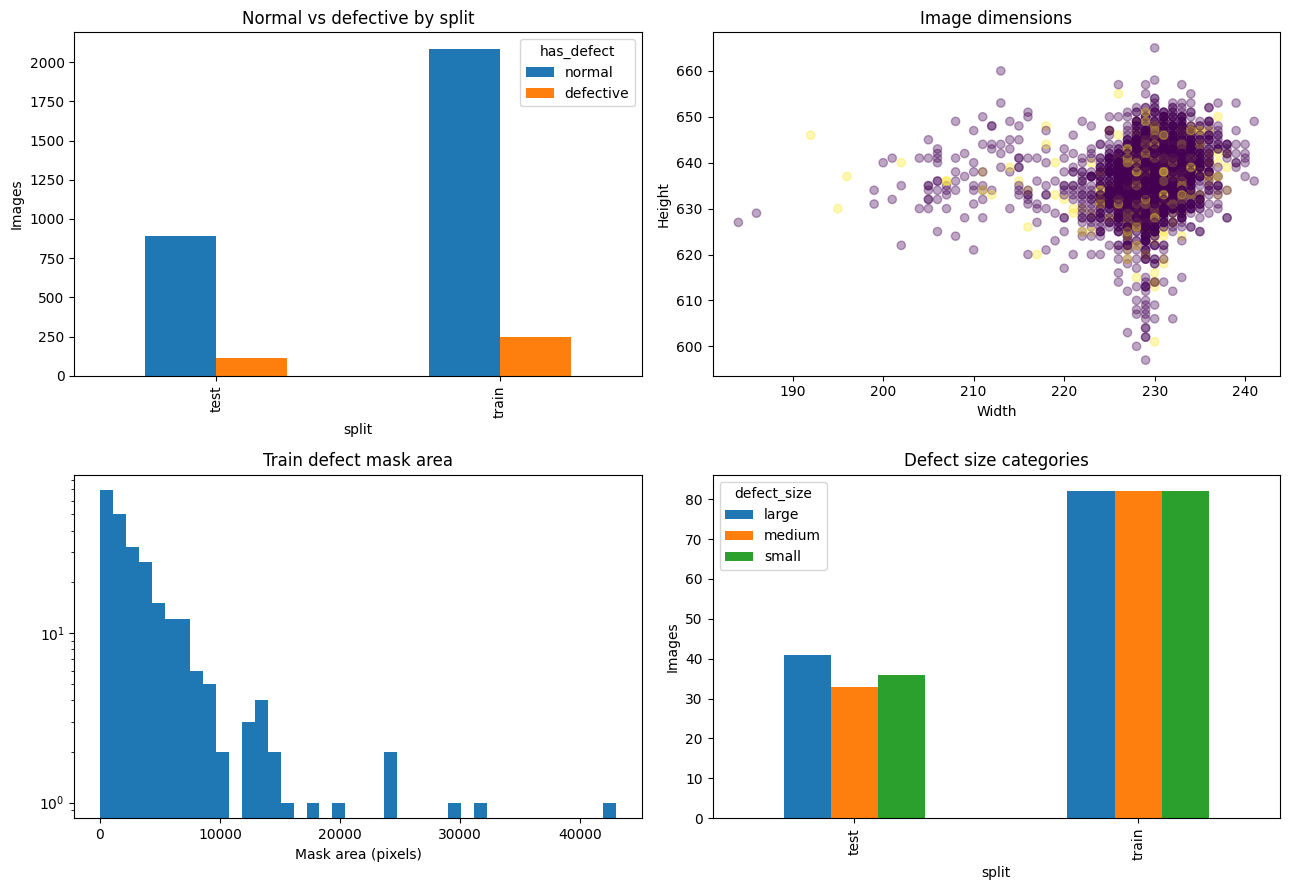

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

counts = df.groupby(["split", "has_defect"]).size().unstack(fill_value=0)
counts.rename(columns={False: "normal", True: "defective"}).plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Normal vs defective by split")
axes[0, 0].set_ylabel("Images")

axes[0, 1].scatter(df["width"], df["height"], c=df["has_defect"].astype(int), alpha=0.35)
axes[0, 1].set_title("Image dimensions")
axes[0, 1].set_xlabel("Width")
axes[0, 1].set_ylabel("Height")

axes[1, 0].hist(train_df.loc[train_df["has_defect"], "mask_area_px"], bins=40)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Train defect mask area")
axes[1, 0].set_xlabel("Mask area (pixels)")

size_counts = df[df["has_defect"]].groupby(["split", "defect_size"]).size().unstack(fill_value=0)
size_counts.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Defect size categories")
axes[1, 1].set_ylabel("Images")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_summary.png", dpi=180)
plt.show()

## 4. Ví dụ ảnh, mask và overlay

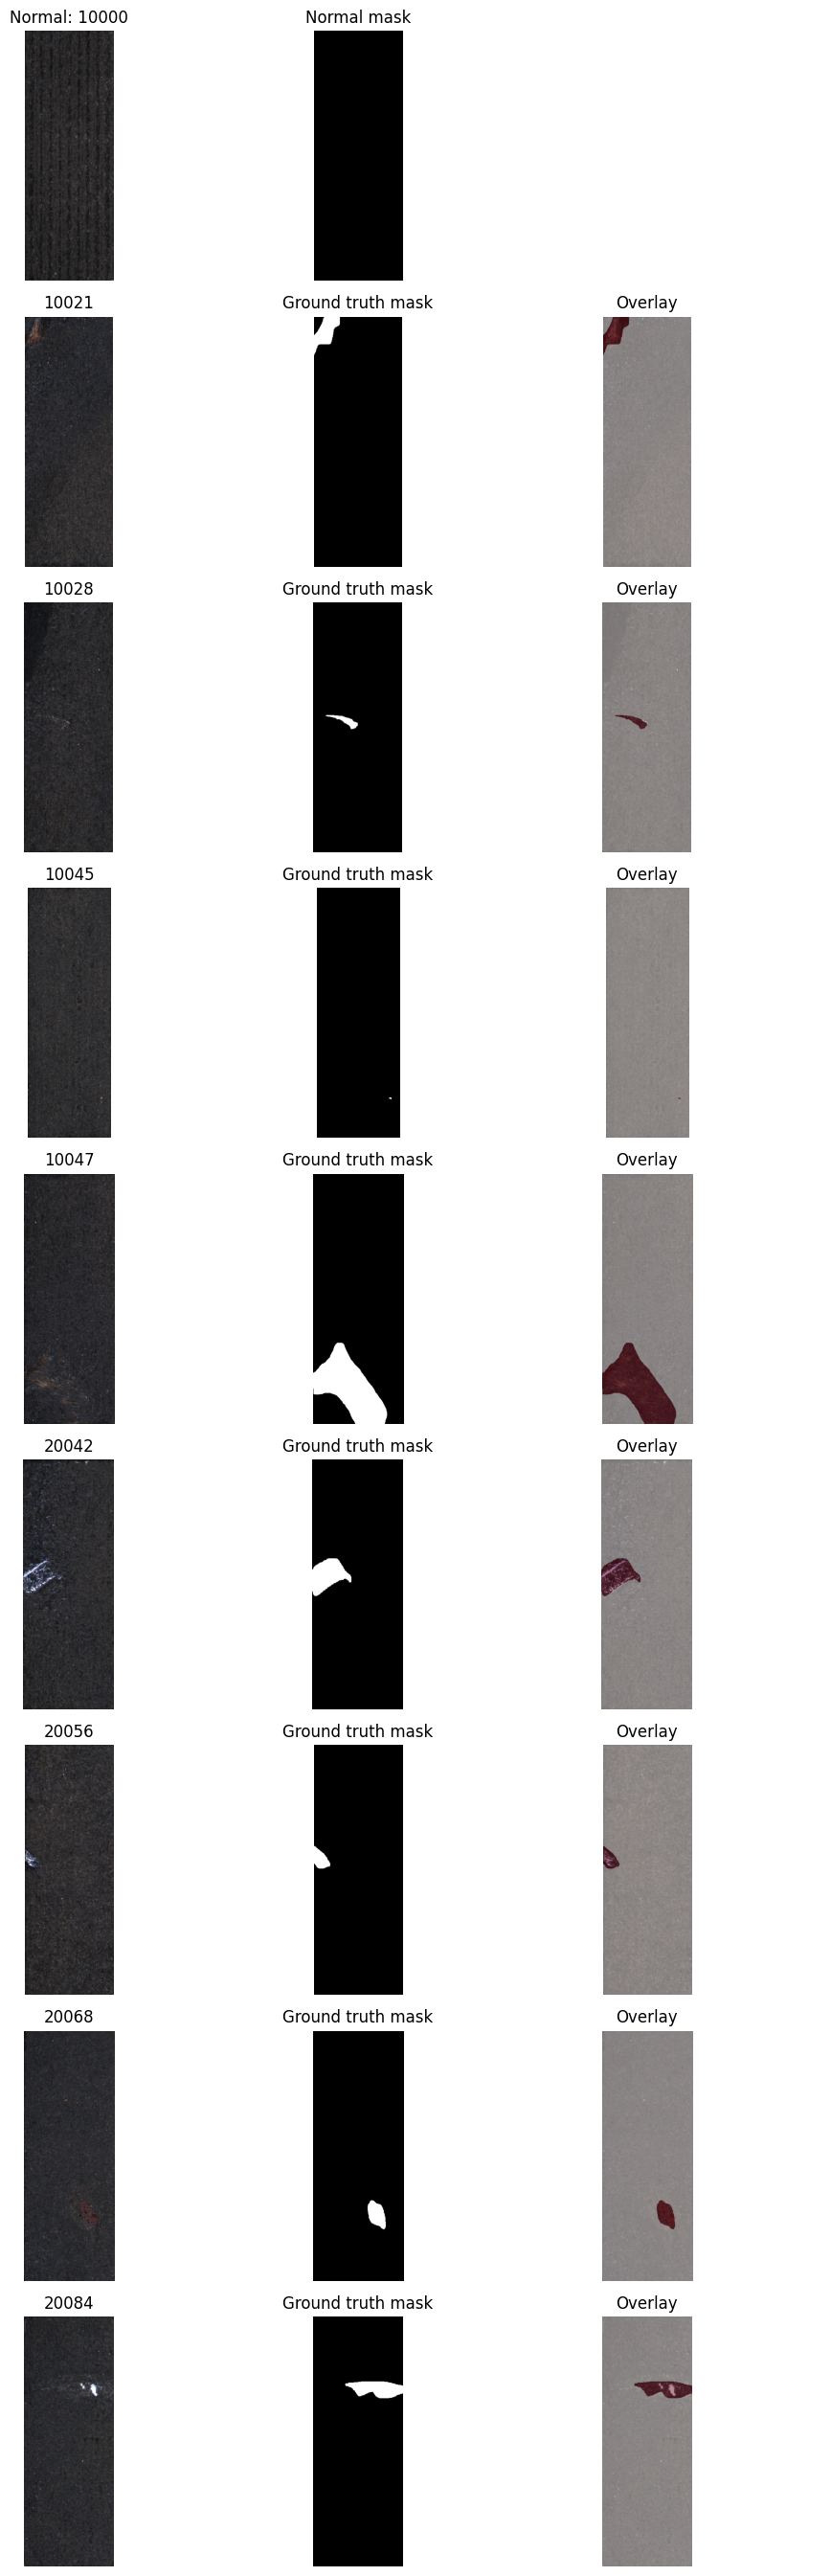

In [7]:
normal_sample = train_df.loc[~train_df["has_defect"]].iloc[0]
normal_path = DATA_ROOT / "train" / "img" / normal_sample["filename"]
normal_image = np.asarray(Image.open(normal_path).convert("RGB"))

examples = train_examples + test_examples
figure, axes = plt.subplots(len(examples) + 1, 3, figsize=(10, 3 * (len(examples) + 1)))
axes = np.atleast_2d(axes)
axes[0, 0].imshow(normal_image)
axes[0, 0].set_title(f"Normal: {normal_sample['image_id']}")
axes[0, 1].imshow(np.zeros(normal_image.shape[:2]), cmap="gray")
axes[0, 1].set_title("Normal mask")
axes[0, 2].axis("off")
for axis in axes[0]:
    axis.axis("off")

for row, (image_id, image, mask) in enumerate(examples, start=1):
    axes[row, 0].imshow(image)
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 2].imshow(image)
    axes[row, 2].imshow(mask, cmap="Reds", alpha=0.45)
    axes[row, 0].set_title(image_id)
    axes[row, 1].set_title("Ground truth mask")
    axes[row, 2].set_title("Overlay")
    for axis in axes[row]:
        axis.axis("off")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "image_mask_overlay_examples.png", dpi=180)
plt.show()

## 5. Checklist output

Sau khi chạy hết notebook, cần có:

- `results/eda/dataset_statistics.csv`
- `results/eda/size_thresholds.json`
- `results/eda/eda_summary.png`
- `results/eda/image_mask_overlay_examples.png`
- train/test counts và integrity không có lỗi
- bảng ngưỡng Small/Medium/Large lấy từ official train defective masks

Official test chỉ được thống kê và dùng sau này cho evaluation; không tạo lại test split trong EDA.